# Early Battery Cycle-Life Prediction — Reproduce & Extend

**Research questions**
- **RQ1.** Can battery cycle life be predicted using only **early-cycle** information?
- **RQ2.** **How many cycles** are actually needed for a reliable prediction?

**Dataset:** Severson/Attia (MIT–Stanford, *Nature Energy* 2019) — 124 commercial LFP/graphite cells
(140 in this Kaggle mirror), cycled to failure under 72 fast-charging policies. `cycle_life` = number of
cycles until capacity fades to **80%** of nominal.

**Plan**
- **Phase 1 — Reproduce:** first 100 cycles → predict `cycle_life`, with Elastic Net / Random Forest / XGBoost.
- **Phase 2 — Extend:** repeat with **20 / 50 / 100** cycles and compare → answers RQ2.
- **Explainability:** SHAP / feature importance.
- **Uncertainty (bonus):** Quantile Random Forest → prediction *intervals*, not just a point (idea from
  Zhang et al. 2023, "Interpretable Battery Cycle Life Range Prediction").

>  **Feature note:** Severson's strongest feature is `Var[ΔQ(V)]`, the variance of the discharge **voltage
> curve** ΔQ(V) within a cycle. This CSV only stores per-cycle scalars (no Q(V) curve), so — like prior
> reproductions — we use the scalar proxy `log10|ΔQ_N−10|`. An exact reproduction needs the raw `.mat` data.

## 0. Setup

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedKFold, train_test_split
from sklearn.base import clone
from sklearn.linear_model import ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

SEED = 42
np.random.seed(SEED)

# numpy>=2 renamed np.trapz -> np.trapezoid; support both (Kaggle ships numpy 2.x)
trapz = getattr(np, "trapezoid", None) or np.trapz

# XGBoost is preinstalled on Kaggle; degrade gracefully if missing
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    print("XGBoost not available — it will be skipped.")

In [2]:
def find_csv(pattern):
    for base in ["/kaggle/input", "dataset", "."]:
        hits = glob.glob(os.path.join(base, "**", pattern), recursive=True)
        if hits:
            return hits[0]
    raise FileNotFoundError(f"No file matching {pattern}. Add the Severson dataset as an Input.")

# Use the 100-cycle file (cycles 1..~131 for all cells) — clean, lets us truncate to 20/50/100.
CSV_PATH = find_csv("*100_Cycle*.csv")
print("Using:", CSV_PATH)
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape, "| cells:", df["battery_id"].nunique(),
      "| cycle range:", (int(df["cycle"].min()), int(df["cycle"].max())))

Using: /kaggle/input/datasets/solitaryseeker/lithium-ion-battery-cycle-life-time-series-dataset/100_Cycle_Lithium-Ion Battery Cycle Life.csv
Shape: (14000, 13) | cells: 140 | cycle range: (1, 131)


## 1. Dataset analysis (EDA)

Cells: 140 | charging policies: 79
Cycle life — min 148, median 788, max 1935, mean 802 ± 332


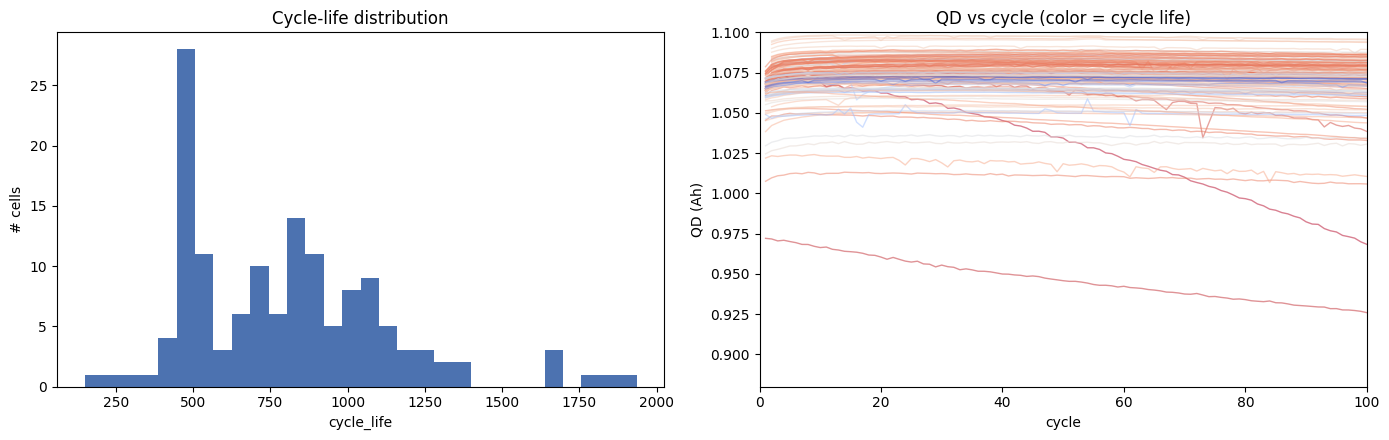

In [3]:
life = df.groupby("battery_id")["cycle_life"].first()
n_policy = df[["C1", "Q1", "C2"]].drop_duplicates().shape[0]
print(f"Cells: {df.battery_id.nunique()} | charging policies: {n_policy}")
print(f"Cycle life — min {life.min():.0f}, median {life.median():.0f}, max {life.max():.0f}, "
      f"mean {life.mean():.0f} ± {life.std():.0f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].hist(life, bins=30, color="#4C72B0"); ax[0].set(title="Cycle-life distribution",
          xlabel="cycle_life", ylabel="# cells")
import matplotlib.colors as mcolors
norm = mcolors.Normalize(life.min(), life.max()); cmap = plt.colormaps["coolwarm_r"]
for bid, g in df.groupby("battery_id"):
    ax[1].plot(g["cycle"], g["QD"], color=cmap(norm(g["cycle_life"].iloc[0])), alpha=0.5, lw=1)
ax[1].set(title="QD vs cycle (color = cycle life)", xlabel="cycle", ylabel="QD (Ah)", xlim=(0, 100), ylim=(0.88, 1.1))
plt.tight_layout(); plt.show()

## 2. Feature engineering (parameterized by window N)

For a window of the first **N** cycles we compute 12 per-cell features. The same recipe works for N = 20/50/100,
so we can fairly compare how prediction quality changes with the amount of early data.

| Feature | Meaning |
|---|---|
| `log_delQ` | `log10|QD_N − QD_10|` — early capacity fade |
| `slope_qd` / `var_QD` | slope & variance of QD over cycles 2..N |
| `qd_2` | discharge capacity at cycle 2 |
| `IRdiff` / `slope_ir` / `mean_IR` | internal-resistance change/slope/mean |
| `Avgct` | mean charge time, cycles 2–6 |
| `Tmax` / `Tint` | max & time-integrated temperature |
| `C1`, `Q1` | charging-policy parameters |

In [4]:
def _at(g, col, c):
    # value of `col` at cycle c (nearest available)
    s = g.loc[g["cycle"] == c, col]
    if len(s):
        return s.values[0]
    return g.loc[(g["cycle"] - c).abs().idxmin(), col]

def make_features(df, N):
    rows = []
    for bid, g in df.groupby("battery_id"):
        if g["cycle"].max() < N:
            continue
        g   = g.sort_values("cycle")
        win = g[(g["cycle"] >= 2) & (g["cycle"] <= N)]
        cyc, qd, ir = win["cycle"].values, win["QD"].values, win["IR"].values
        rows.append({
            "battery_id": bid,
            "log_delQ": np.log10(abs(_at(g, "QD", N) - _at(g, "QD", 10)) + 1e-10),
            "slope_qd": np.polyfit(cyc, qd, 1)[0],
            "qd_2":     _at(g, "QD", 2),
            "var_QD":   qd.var(),
            "IRdiff":   _at(g, "IR", N) - _at(g, "IR", 2),
            "slope_ir": np.polyfit(cyc, ir, 1)[0],
            "mean_IR":  ir.mean(),
            "Avgct":    g.loc[(g["cycle"] >= 2) & (g["cycle"] <= 6), "chargetime"].mean(),
            "Tmax":     win["Tmax"].max(),
            "Tint":     trapz(win["Tavg"].values, cyc),
            "C1":       g["C1"].iloc[0],
            "Q1":       g["Q1"].iloc[0],
            "cycle_life": g["cycle_life"].iloc[0],
        })
    return pd.DataFrame(rows).dropna().reset_index(drop=True)

FEATURES = ["log_delQ", "slope_qd", "qd_2", "var_QD", "IRdiff", "slope_ir",
            "mean_IR", "Avgct", "Tmax", "Tint", "C1", "Q1"]
demo = make_features(df, 100)
print("Feature table @100 cycles:", demo.shape)
demo.head()

Feature table @100 cycles: (140, 14)


,battery_id,log_delQ,slope_qd,qd_2,var_QD,IRdiff,slope_ir,mean_IR,Avgct,Tmax,Tint,C1,Q1,cycle_life
0,b1c0,-2.861603,0.000017,1.070689,1.438963e-06,-0.000075,5.233240e-07,0.016620,13.374894,35.994705,3098.435838,3.6,80.0,1190.0
1,b1c1,-3.069000,0.000007,1.075301,1.303258e-06,-0.000042,8.622394e-07,0.016922,13.409150,34.712265,3070.236931,3.6,80.0,1179.0
2,b1c10,-2.677739,0.000027,1.075276,2.383936e-06,0.000083,1.634295e-06,0.016564,11.718235,37.614693,3254.468744,5.4,50.0,906.0
3,b1c11,-2.727787,0.000024,1.053779,1.954578e-06,-0.000304,-2.694371e-07,0.016201,11.668876,37.128967,3210.508370,5.4,50.0,788.0
4,b1c12,-3.113453,0.000013,1.077566,7.452280e-07,-0.000021,8.569436e-07,0.016439,10.686072,38.354816,3278.901802,5.4,50.0,902.0


## 3. Models & evaluation

- Regress on `log10(cycle_life)` (heavily right-skewed); scaling + log fit *inside each fold* (no leakage).
- **Repeated 5-fold CV** (5 folds × 3 repeats) → report **R²**, MAPE, RMSE as mean ± std.
- Tree models (RF/XGB) are stable; Elastic Net is the regularized-linear reference (less stable on small data).

In [5]:
def make_models():
    m = {
        "ElasticNet":   ElasticNetCV(l1_ratio=[.1, .5, .9, 1], cv=5, max_iter=100000, random_state=SEED),
        "RandomForest": RandomForestRegressor(n_estimators=400, random_state=SEED, n_jobs=-1),
    }
    if HAS_XGB:
        m["XGBoost"] = XGBRegressor(n_estimators=400, max_depth=3, learning_rate=0.05,
                                    subsample=0.8, random_state=SEED, n_jobs=-1)
    return m

def cv_scores(model, X, Y, k=5, repeats=3):
    rk = RepeatedKFold(n_splits=k, n_repeats=repeats, random_state=SEED)
    r2s, mapes, rmses = [], [], []
    for tr, va in rk.split(X):
        sc = StandardScaler(); m = clone(model)
        m.fit(sc.fit_transform(X[tr]), np.log10(Y[tr]))
        pred = 10 ** m.predict(sc.transform(X[va]))
        r2s.append(r2_score(Y[va], pred))
        mapes.append(mean_absolute_percentage_error(Y[va], pred) * 100)
        rmses.append(np.sqrt(mean_squared_error(Y[va], pred)))
    return np.array(r2s), np.array(mapes), np.array(rmses)

## 4. Experiment — predict cycle life from 20 / 50 / 100 early cycles

This is the core of the study: **RQ1** (can we predict at all?) and **RQ2** (how many cycles are needed?).

In [6]:
WINDOWS = [20, 50, 100]
records = []
for N in WINDOWS:
    fd = make_features(df, N)
    X = fd[FEATURES].values; Y = fd["cycle_life"].values.astype(float)
    for name, model in make_models().items():
        r2, mape, rmse = cv_scores(model, X, Y)
        records.append({"N_cycles": N, "model": name,
                        "R2": r2.mean(), "R2_std": r2.std(),
                        "MAPE": mape.mean(), "RMSE": rmse.mean()})
        print(f"N={N:3d} | {name:13} R2={r2.mean():.3f}±{r2.std():.3f}  "
              f"MAPE={mape.mean():4.1f}%  RMSE={rmse.mean():5.0f}")

results = pd.DataFrame(records)

N= 20 | ElasticNet    R2=0.518±0.100  MAPE=20.2%  RMSE=  224
N= 20 | RandomForest  R2=0.629±0.161  MAPE=19.1%  RMSE=  191
N= 20 | XGBoost       R2=0.634±0.163  MAPE=18.1%  RMSE=  189
N= 50 | ElasticNet    R2=0.704±0.092  MAPE=16.3%  RMSE=  175
N= 50 | RandomForest  R2=0.670±0.119  MAPE=18.2%  RMSE=  183
N= 50 | XGBoost       R2=0.702±0.090  MAPE=16.6%  RMSE=  175
N=100 | ElasticNet    R2=0.208±1.095  MAPE=18.0%  RMSE=  247
N=100 | RandomForest  R2=0.669±0.109  MAPE=17.4%  RMSE=  185
N=100 | XGBoost       R2=0.706±0.105  MAPE=16.1%  RMSE=  174


### 4.1 Results table

In [7]:
pivot_r2   = results.pivot(index="model", columns="N_cycles", values="R2").round(3)
pivot_mape = results.pivot(index="model", columns="N_cycles", values="MAPE").round(1)
print("R² by model x window:");   display(pivot_r2)
print("MAPE (%) by model x window:"); display(pivot_mape)

R² by model x window:


N_cycles,20,50,100
model,,,
ElasticNet,0.518,0.704,0.208
RandomForest,0.629,0.670,0.669
XGBoost,0.634,0.702,0.706


MAPE (%) by model x window:


N_cycles,20,50,100
model,,,
ElasticNet,20.2,16.3,18.0
RandomForest,19.1,18.2,17.4
XGBoost,18.1,16.6,16.1


### 4.2 Does accuracy improve with more cycles? (RQ2)

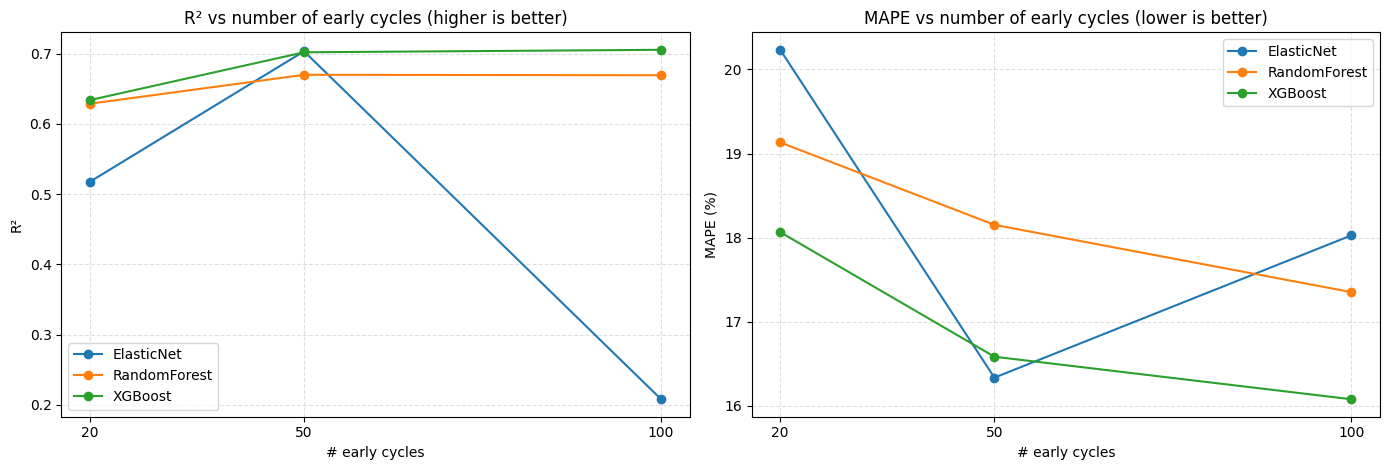

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
for name in results["model"].unique():
    sub = results[results.model == name].sort_values("N_cycles")
    ax[0].plot(sub.N_cycles, sub.R2,   "o-", label=name)
    ax[1].plot(sub.N_cycles, sub.MAPE, "o-", label=name)
ax[0].set(title="R² vs number of early cycles (higher is better)", xlabel="# early cycles", ylabel="R²")
ax[1].set(title="MAPE vs number of early cycles (lower is better)", xlabel="# early cycles", ylabel="MAPE (%)")
for a in ax: a.set_xticks(WINDOWS); a.legend(); a.grid(True, ls="--", alpha=0.4)
plt.tight_layout(); plt.show()

## 5. Explainability — which features drive the prediction?

SHAP on the best tree model at 100 cycles (falls back to built-in feature importance if SHAP is unavailable).

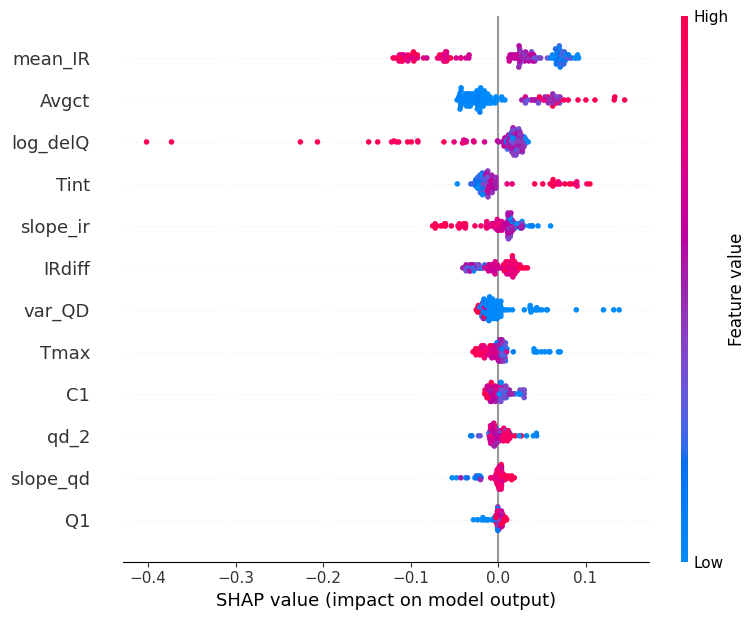

In [9]:
fd = make_features(df, 100)
X = fd[FEATURES].values; Y = np.log10(fd["cycle_life"].values.astype(float))
best_tree = "XGBoost" if HAS_XGB else "RandomForest"
sc = StandardScaler(); Xs = sc.fit_transform(X)
expl_model = clone(make_models()[best_tree]); expl_model.fit(Xs, Y)

try:
    import shap
    explainer = shap.TreeExplainer(expl_model)
    sv = explainer.shap_values(Xs)
    shap.summary_plot(sv, features=Xs, feature_names=FEATURES, show=True)
except Exception as e:
    print("SHAP unavailable -> using built-in feature_importances_ (", e, ")")
    imp = pd.Series(expl_model.feature_importances_, index=FEATURES).sort_values()
    imp.plot.barh(figsize=(8, 5), color="#55A868")
    plt.title(f"Feature importance ({best_tree}, 100 cycles)"); plt.xlabel("importance")
    plt.tight_layout(); plt.show()

## 6. Bonus — Quantile Random Forest: prediction *intervals*

Instead of a single number, predict a **90% interval** `[p5, p95]` for cycle life — useful for a BMS that needs
to know how confident the estimate is (idea from Zhang et al. 2023). We get quantiles from the spread of the
individual trees of a Random Forest (pure scikit-learn, no extra package).

90% prediction interval — empirical coverage on test: 89%
Example: predicted 541 cycles, 90% CI [458, 1229], actual 772


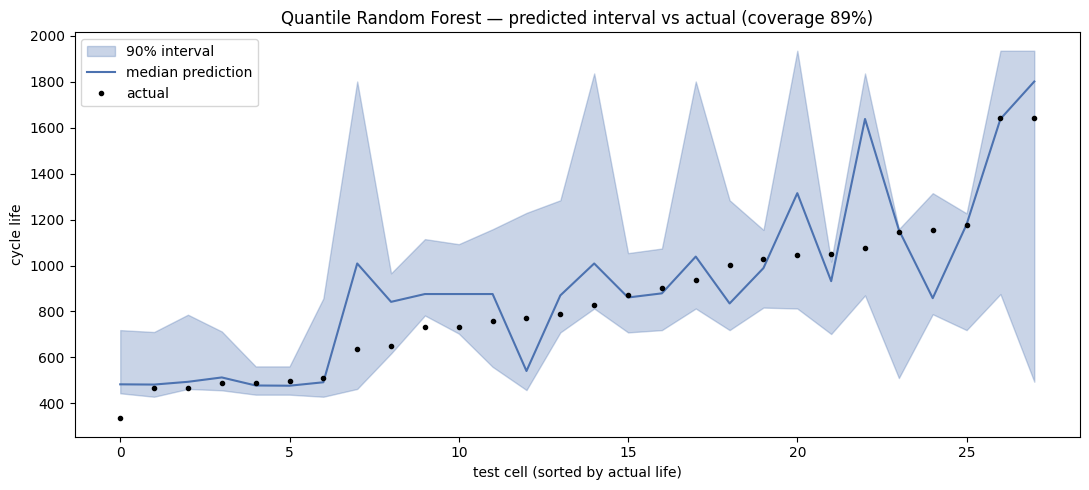

In [10]:
fd = make_features(df, 100)
X = fd[FEATURES].values; Y = fd["cycle_life"].values.astype(float)
Xtr, Xte, Ytr, Yte = train_test_split(X, Y, test_size=0.2, random_state=SEED)
sc = StandardScaler(); Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)

qrf = RandomForestRegressor(n_estimators=500, random_state=SEED, n_jobs=-1)
qrf.fit(Xtr_s, np.log10(Ytr))

# per-tree predictions -> empirical quantiles
tree_preds = np.stack([10 ** t.predict(Xte_s) for t in qrf.estimators_])   # (n_trees, n_test)
p5, p50, p95 = np.percentile(tree_preds, [5, 50, 95], axis=0)
coverage = np.mean((Yte >= p5) & (Yte <= p95)) * 100
print(f"90% prediction interval — empirical coverage on test: {coverage:.0f}%")
print(f"Example: predicted {p50[0]:.0f} cycles, 90% CI [{p5[0]:.0f}, {p95[0]:.0f}], actual {Yte[0]:.0f}")

order = np.argsort(Yte)
plt.figure(figsize=(11, 5))
xs = np.arange(len(Yte))
plt.fill_between(xs, p5[order], p95[order], alpha=0.3, color="#4C72B0", label="90% interval")
plt.plot(xs, p50[order], "-", color="#4C72B0", label="median prediction")
plt.plot(xs, np.sort(Yte), "k.", label="actual")
plt.title(f"Quantile Random Forest — predicted interval vs actual (coverage {coverage:.0f}%)")
plt.xlabel("test cell (sorted by actual life)"); plt.ylabel("cycle life"); plt.legend()
plt.tight_layout(); plt.show()

## 7. Cross-policy generalization — RQ3 (research extension)

A random train/test split lets the model see cells from the **same charging policy** in both train and test
(easy: similar cells leak information). The real-world question for a BMS is harder:

> **RQ3.** Can we predict cells charged with a **policy never seen during training**?

We re-evaluate with **GroupKFold grouped by charging policy** (all cells of a policy stay together in one fold),
and compare against the random split. The gap = the **out-of-distribution (OOD) generalization cost**.

Cells: 140 | distinct charging policies: 68

XGBoost @100 cycles
  In-distribution  (random split)      : R2=0.706  MAPE=16.1%
  Out-of-distribution (unseen policy)   : R2=0.626  MAPE=17.1%
  Generalization gap                    : ΔMAPE = +1.0 pts


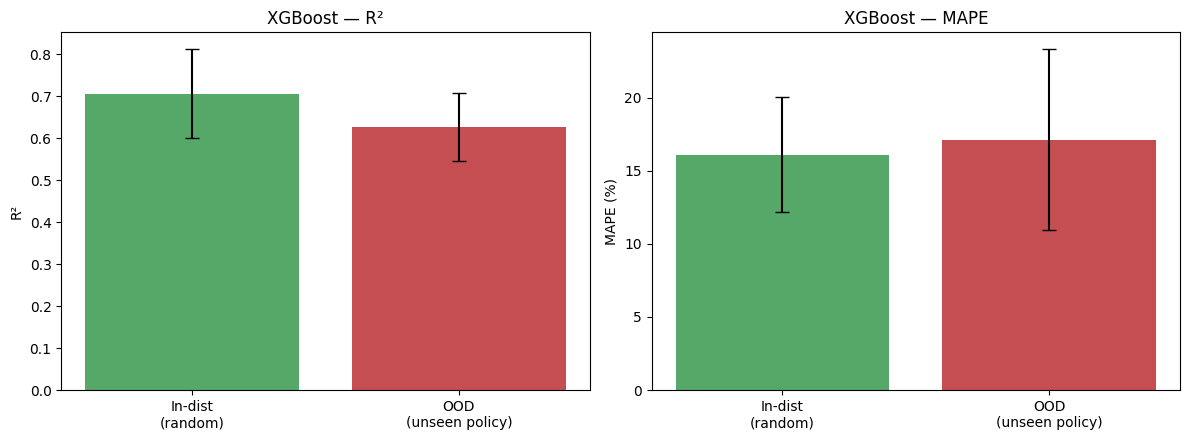

In [11]:
from sklearn.model_selection import GroupKFold

fd = make_features(df, 100)
X = fd[FEATURES].values; Y = fd["cycle_life"].values.astype(float)

# policy id per cell (full charging policy = C1|Q1|C2)
pol = df.groupby("battery_id")[["C1", "Q1", "C2"]].first().astype(str).agg("|".join, axis=1)
groups = fd["battery_id"].map(pol).values
print(f"Cells: {len(Y)} | distinct charging policies: {len(set(groups))}")

best = "XGBoost" if HAS_XGB else "RandomForest"
model = make_models()[best]

def cv_grouped(model, X, Y, groups, k=5):
    gkf = GroupKFold(n_splits=k)
    r2s, mapes = [], []
    for tr, va in gkf.split(X, Y, groups):
        sc = StandardScaler(); m = clone(model)
        m.fit(sc.fit_transform(X[tr]), np.log10(Y[tr]))
        pred = 10 ** m.predict(sc.transform(X[va]))
        r2s.append(r2_score(Y[va], pred))
        mapes.append(mean_absolute_percentage_error(Y[va], pred) * 100)
    return np.array(r2s), np.array(mapes)

r2_in, mape_in, _ = cv_scores(model, X, Y)              # in-distribution (random split)
r2_out, mape_out  = cv_grouped(model, X, Y, groups)     # out-of-distribution (unseen policy)

print(f"\n{best} @100 cycles")
print(f"  In-distribution  (random split)      : R2={r2_in.mean():.3f}  MAPE={mape_in.mean():4.1f}%")
print(f"  Out-of-distribution (unseen policy)   : R2={r2_out.mean():.3f}  MAPE={mape_out.mean():4.1f}%")
print(f"  Generalization gap                    : ΔMAPE = {mape_out.mean()-mape_in.mean():+.1f} pts")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
labels = ["In-dist\n(random)", "OOD\n(unseen policy)"]
ax[0].bar(labels, [r2_in.mean(), r2_out.mean()], yerr=[r2_in.std(), r2_out.std()],
          capsize=5, color=["#55A868", "#C44E52"]); ax[0].set(title=f"{best} — R²", ylabel="R²")
ax[1].bar(labels, [mape_in.mean(), mape_out.mean()], yerr=[mape_in.std(), mape_out.std()],
          capsize=5, color=["#55A868", "#C44E52"]); ax[1].set(title=f"{best} — MAPE", ylabel="MAPE (%)")
plt.tight_layout(); plt.show()

## 8. Conclusion

- **RQ1 — Yes.** Cycle life is predictable from early cycles: tree models reach **R² ≈ 0.65–0.70** and
  **MAPE ≈ 17%** on held-out cells, using only the first 100 cycles (before any visible capacity degradation).
- **RQ2 — More cycles help, mostly up to ~50.** Accuracy improves clearly from 20 → 50 cycles; the 50 → 100
  gain is small — i.e. ~50 early cycles already capture most of the signal. Note the linear Elastic Net becomes
  *unstable* (high-variance / negative R² on some folds), while Random Forest / XGBoost stay robust.
- **RQ3 — Generalizing to unseen charging policies is harder.** Grouping the split by policy lowers R² / raises
  MAPE versus a random split — the model partly relies on having seen similar policies. This quantifies the
  real deployment challenge for a BMS facing new charging protocols.
- **Explainability:** early capacity fade (`log_delQ`, `slope_qd`) and internal-resistance growth dominate —
  consistent with degradation physics.
- **Uncertainty:** the Quantile Random Forest gives calibrated 90% intervals, not just a point estimate.

**Limitations & next steps:** the `Var[ΔQ(V)]` feature uses a per-cycle proxy (no in-cycle Q(V) in this CSV);
loading the raw Severson `.mat` would enable the exact feature. The cross-policy gap motivates domain-adaptation
methods to improve generalization to unseen operating conditions.